<a href="https://colab.research.google.com/github/instrat-pl/pypsa-pl/blob/main/notebooks/pypsa_pl_mini_capex_all_grids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyPSA-PL-mini: OPEX+CAPEX, all sectors with power grids

Simplified energy model for rapid testing and education.

Example of joint OPEX and CAPEX optimisation for all sectors, including power grids at the voivodeship level.

Version 1.0

This notebook is released under [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact person:** Patryk Kubiczek (patryk.kubiczek@instrat.pl)

## How to use it?

**Start by making your own copy of this notebook (File > Save a copy in Drive).** This notebook, containing an application of the  PyPSA-PL-mini model, is synchronised with the GitHub repository https://github.com/instrat-pl/pypsa-pl. To play with the model, create your own copy of this notebook. 

Run the "Configuration" cells which will clone the PyPSA-PL repository into your Google Colab space and which will install all the required libraries. This might take up to a few minutes. After the configuration is finished, you can proceed to experiment with PyPSA-PL-mini. Have fun!

## Configuration (run each cell just once)

In [1]:
import sys
import os

# Optionally install pl_PL.UTF-8 locale in Google Colab
# Source: https://stackoverflow.com/questions/67045349/change-locale-for-google-colab

skip_installing_pl_locale = True

if "google.colab" in sys.modules and not skip_installing_pl_locale:
  # Install pl_PL
  !/usr/share/locales/install-language-pack pl_PL.UTF-8
  !dpkg-reconfigure locales
    
  # Restart Python process to pick up the new locales
  os.kill(os.getpid(), 9)

In [2]:
import sys
import os
from pathlib import Path

instrat_user = False
force_installation = False

if "google.colab" in sys.modules:

  %cd "/content"

  if instrat_user:  
    
    from google.colab import drive
    root = "/content/drive"
    drive.mount(root)

    def project_dir(*path):
      return Path(root, "MyDrive", "Colab", "PyPSA-PL-mini", *path)

  else:
    
    from google.colab import userdata
    # ghtoken = userdata.get("GHTOKEN")

    !rm -rf pypsa-pl
    # !git clone https://{ghtoken}@github.com/instrat-pl/pypsa-pl.git
    !git clone https://github.com/instrat-pl/pypsa-pl.git

    def project_dir(*path):
      return Path("/content", "pypsa-pl", *path)

  %cd {str(project_dir())}

  if not instrat_user or force_installation:
    !pip install poetry --quiet
    !poetry config virtualenvs.in-project false
    !poetry config virtualenvs.path {str(project_dir("venv"))}
    !poetry install --no-ansi
    # ipywidgets have to be downgraded in Google Colab
    !poetry add ipywidgets@7.7.2 --no-ansi
    # Download and install Work Sans font
    !mkdir fonts
    %cd fonts  
    !wget https://github.com/weiweihuanghuang/Work-Sans/raw/master/fonts/ttf/WorkSans-Regular.ttf
    !wget https://github.com/weiweihuanghuang/Work-Sans/raw/master/fonts/ttf/WorkSans-Medium.ttf
    from matplotlib import font_manager
    font_files = ["WorkSans-Regular.ttf", "WorkSans-Medium.ttf"]
    for font_file in font_files:
        font_manager.fontManager.addfont(font_file)
    %cd ..

  v = f"{sys.version_info.major}.{sys.version_info.minor}"
  venv_location = !poetry env info -p
  VENV_PATH = os.path.join(venv_location[0], "lib", f"python{v}", "site-packages")
  sys.path.insert(0, VENV_PATH)  
  
  SRC_PATH = str(project_dir("src"))
  sys.path.insert(0, SRC_PATH)

else:

  from pypsa_pl.config import project_dir

  %load_ext autoreload
  %autoreload 2

import pypsa_pl.config

## Energy system model

### Specify parameters

In [3]:
params = {
    # Run name and year
    "run_name": "pypsa_pl_mini_capex_all_grids",
    "year": 2024,
    # Input data
    "technology_carrier_definitions": "full",
    "technology_cost_data": "instrat_2025",
    "installed_capacity": [
        "historical_totals_voivodeships",
        "transmission_grid_voivodeships",
    ],
    "annual_energy_flows": "historical_voivodeships",
    "capacity_utilisation": "historical",
    "capacity_addition_potentials": [
        "instrat_res_potentials_voivodeships",
        "instrat_other_potentials_voivodeships",
    ],
    "timeseries": "mini",
    # CO2 emissions
    "co2_emissions": None,  # no limit on CO2 emissions
    # Weather year
    "weather_year": 2012,
    # Other assumptions
    "discount_rate": 0.045,
    "investment_cost_start_year": 2021,
    "invest_from_zero": True,
    "optimise_industrial_capacities": False,
    "investment_technologies": [
        # Power
        "wind onshore",
        "solar PV ground",
        "battery large power",
        "battery large charger",
        "battery large storage",
        # Heating - centralised
        "heat pump large AW",
        "resistive heater large",
        "heat storage large tank discharge",
        "heat storage large tank charge",
        "heat storage large tank",
        # Heating - decentralised
        "heat pump small AW",
        "resistive heater small",
        "heat storage small discharge",
        "heat storage small charge",
        "heat storage small",
        # ***
        "hard coal boiler",
        # ***
        # Mobility
        "BEV",
        "BEV battery",
        "BEV charger",
        # "BEV V2G", # if V2G scale factor is zero, do not optimise
        # Hydrogen
        "hydrogen electrolysis",
        "hydrogen storage",
    ],
    "retirement_technologies": [
        # Power
        # "hard coal power old",
        # "hard coal power SC",
        # "lignite power old",
        # "lignite power SC",
        # CHP
        "hard coal CHP",
        # Heating - centralised
        "hard coal heat",
        # Heating - decentralised
        "hard coal boiler",
        "natural gas boiler",
        "other boiler",
        # Mobility
        "ICE vehicle",
        # Hydrogen
        "natural gas reforming",
        # Virtual components - always need to be included
        "centralised space heating",
        "centralised water heating",
        "centralised other heating",
        "decentralised space heating",
        "decentralised water heating",
        "light vehicle mobility",
        "hydrogen",
    ],
    "constrained_energy_flows": [
        "space heating final use",
        "water heating final use",
        "other heating final use",
        "light vehicle mobility final use",
        "hydrogen final use",
    ],
    "reoptimise_with_fixed_capacities": False,  # if True, only OPEX determines marginal prices
    # CHP behavior
    "fix_public_chp": False,
    "fix_industrial_chp": True,
    "share_space_heating": 0.75,
    # Electricity sector
    "prosumer_self_consumption": 0.2,
    "p_min_synchronous": 0,  # irrelevant in this example - we set p_min_pu for thermal power plants
    "synchronous_carriers": [],
    # Heating sector
    "heat_capacity_utilisation": 0.2,
    "centralised_heating_share": None,  # determined by district heating capacities
    # Light vehicle mobility sector
    "light_vehicle_mobility_utilisation": 0.021,
    "bev_flexibility_factor": 0.5,
    "bev_flexibility_max_to_mean_ratio": 1.33,
    "bev_flexible_share": 0.5,  # if exact 0 is desired, set bev_flexibility_factor=0 instead
    "bev_availability_max": 0.9,
    "bev_availability_mean": 0.7,
    # "minimum_bev_charge_level": 0.75,
    # "minimum_bev_charge_hour": 6,
    # Technical details - they should not influence numerical results
    "space_heating_utilisation": 0.1,
    "water_heating_utilisation": 1,
    "other_heating_utilisation": 1,
    "hydrogen_utilisation": 1,
    "inf": 999999,
    "reverse_links": True,
    "solver": "gurobi",
    "solver_tolerance": 1e-6,
}

### Prepare inputs


In [4]:
import logging
import numpy as np
from pypsa_pl.build_network import load_and_preprocess_inputs


def custom_operation(inputs, params):

    voivodeships = [
        "PL dolnośląskie",
        "PL kujawsko-pomorskie",
        "PL lubelskie",
        "PL lubuskie",
        "PL łódzkie",
        "PL małopolskie",
        "PL mazowieckie",
        "PL opolskie",
        "PL podkarpackie",
        "PL podlaskie",
        "PL pomorskie",
        "PL śląskie",
        "PL świętokrzyskie",
        "PL warmińsko-mazurskie",
        "PL wielkopolskie",
        "PL zachodniopomorskie",
    ]

    def add_qualifier_to_technology(df, technology, qualifier):
        df.loc[df["technology"] == technology, "qualifier"] = qualifier
        return df

    # Identify solar PV roof as prosumer electricity source
    inputs["installed_capacity"] = add_qualifier_to_technology(
        inputs["installed_capacity"],
        "solar PV roof",
        "prosumer",
    )

    def remove_capacities(df, technologies):
        df = df[~df["technology"].isin(technologies)]
        return df

    # We do not model cross border electricity flows in this simplified example
    inputs["installed_capacity"] = remove_capacities(
        inputs["installed_capacity"],
        technologies=[
            "electricity export AC",
            "electricity import AC",
            "electricity export DC",
            "electricity import DC",
            # Remove centralised other heating
            # "centralised other heating",
            # "centralised water heating",
            # "decentralised water heating",
            # "other heating final use",
            # "water heating final use",
        ],
    )

    def remove_p_max_pu_annual_technology_input(df, keep_techs=[]):
        df = df[
            ~(df["parameter"] == "p_max_pu_annual")
            | df["technology"].isin(keep_techs)
            | df["technology"].str.startswith(("wind", "solar"))
        ]
        return df

    inputs["technology_cost_data"] = remove_p_max_pu_annual_technology_input(
        inputs["technology_cost_data"],
        keep_techs=["nuclear power large"],
    )

    def remove_chp_capacity_utilisation_input(df, qualifiers=["public", "industrial"]):
        df = df[
            ~(df["technology"].str.contains("CHP") & df["qualifier"].isin(qualifiers))
        ]
        return df

    qualifiers = []
    if not params["fix_public_chp"]:
        qualifiers += ["public"]
    if not params["fix_industrial_chp"]:
        qualifiers += ["industrial"]
    inputs["capacity_utilisation"] = remove_chp_capacity_utilisation_input(
        inputs["capacity_utilisation"], qualifiers=qualifiers
    )

    def rescale_v2g(df_tech, df_cap, factor):
        df_tech.loc[
            (df_tech["technology"] == "BEV V2G")
            & (df_tech["parameter"] == "parent_ratio"),
            "value",
        ] *= factor
        df_cap.loc[df_cap["technology"] == "BEV V2G", "nom"] *= factor
        return df_tech, df_cap

    inputs["technology_cost_data"], inputs["installed_capacity"] = rescale_v2g(
        inputs["technology_cost_data"],
        inputs["installed_capacity"],
        factor=0,
    )

    def add_p_min_pu_constraint(df, technology, qualifier="", p_min_pu=0):
        df["qualifier"] = df["qualifier"].fillna("")
        df = df.set_index(["area", "technology", "qualifier", "year", "parameter"])
        df.loc[("PL", technology, qualifier, params["year"], "p_min_pu"), "value"] = (
            p_min_pu
        )
        df = df.reset_index()
        df["qualifier"] = df["qualifier"].replace("", np.nan)
        return df

    # Add 50% minimum load constraint for nuclear power plants
    inputs["capacity_utilisation"] = add_p_min_pu_constraint(
        inputs["capacity_utilisation"], "nuclear power large", p_min_pu=0.5
    )

    def subtract_endogenous_electricity_consumption_and_losses(df_flow, df_cap):
        grid_loss = 0.070
        efficiency = {
            "resistive heater small": 1,
            "heat pump small AW": 3.1,
            "BEV": 0.85 * 0.9,
        }
        utilisation = {
            "resistive heater small": params["heat_capacity_utilisation"],
            "heat pump small AW": params["heat_capacity_utilisation"],
            "BEV": params["light_vehicle_mobility_utilisation"],
        }

        # Identify sectoral electricity demand sources
        df = df_cap.loc[
            (
                (df_cap["technology"] == "resistive heater small")
                & (df_cap["bus_qualifier"] == "resistive heater")
                # There are also resistive heaters supporting heat pumps - we assume they have negligibly small utilisation
            )
            | (df_cap["technology"] == "heat pump small AW")
            | (df_cap["technology"] == "BEV"),
            ["area", "technology", "build_year", "nom"],
        ].rename(columns={"build_year": "year", "nom": "sectoral_consumption"})
        # Calculate final energy demand in TWh from capacities and utilisation
        df["sectoral_consumption"] *= 8760 * df["technology"].map(utilisation) / 1e6
        # Calculate sectoral electricity consumption taking into account technology efficiency
        df["sectoral_consumption"] /= df["technology"].map(efficiency)

        # Aggregate and merge on df_flow
        df = df.drop(columns="technology").groupby(["area", "year"]).sum().reset_index()
        sectoral_consumption = df.loc[
            df["year"] == params["year"], "sectoral_consumption"
        ].sum()
        df_flow = df_flow.merge(df, on=["area", "year"], how="left")

        # (1) Subtract electricity grid losses
        is_electricity_final_use = df_flow["carrier"].str.startswith(
            "electricity"
        ) & df_flow["carrier"].str.endswith("final use")
        df_flow.loc[is_electricity_final_use, "value"] *= 1 - grid_loss
        logging.info(
            f"Subtracting {(grid_loss * 100):.1f}% electricity distribution loss"
        )

        # (2) Subtract sectoral electricity consumption (all is at LV)
        df_flow["sectoral_consumption"] *= -1
        is_electricity_LV_final_use = df_flow["carrier"] == "electricity LV final use"
        df_flow.loc[is_electricity_LV_final_use, "value"] = df_flow.loc[
            is_electricity_LV_final_use, ["value", "sectoral_consumption"]
        ].sum(axis=1)
        df_flow = df_flow.drop(columns="sectoral_consumption")
        logging.info(
            f"Subtracting endogenous sectoral electricity consumption: {sectoral_consumption:.1f} TWh ({params['year']})"
        )

        df_flow["value"] = df_flow["value"].round(2)

        return df_flow

    inputs["annual_energy_flows"] = (
        subtract_endogenous_electricity_consumption_and_losses(
            inputs["annual_energy_flows"], inputs["installed_capacity"]
        )
    )

    def add_new_capacities(df, technologies_qualifiers, nom=0, cumulative=False):
        df = df.set_index("name")
        for area in voivodeships:
            for (
                technology,
                qualifier,
                bus_qualifier,
                bus_from_qualifier,
                bus2_qualifier,
            ) in technologies_qualifiers:
                area_from = np.nan
                build_year = params["year"]
                retire_year = np.nan if not cumulative else params["year"]
                length = np.nan
                # Determine name
                name = f"{area} {technology}" + (
                    f" {qualifier}" if qualifier is not np.nan else ""
                )
                bus_qualifier_suffix = " ".join(
                    set(
                        [
                            x
                            for x in [bus_qualifier, bus_from_qualifier, bus2_qualifier]
                            if x is not np.nan
                        ]
                    )
                )
                name += f" {bus_qualifier_suffix}" if bus_qualifier_suffix != "" else ""
                name += " new"
                df.loc[name] = [
                    area,
                    area_from,
                    technology,
                    qualifier,
                    bus_qualifier,
                    bus_from_qualifier,
                    bus2_qualifier,
                    build_year,
                    retire_year,
                    cumulative,
                    nom,
                    length,
                ]
        df = df.reset_index()
        return df

    # Add candidate capacities to extend
    inputs["installed_capacity"] = add_new_capacities(
        inputs["installed_capacity"],
        technologies_qualifiers=[
            # Power
            ("wind onshore", np.nan, "HMV vRES", np.nan, np.nan),
            ("solar PV ground", np.nan, "HMV vRES", np.nan, np.nan),
            ("battery large power", np.nan, "HMV", "HMV", np.nan),
            ("battery large charger", np.nan, "HMV", "HMV", np.nan),
            ("battery large storage", np.nan, "HMV", np.nan, np.nan),
            # Heating - centralised
            *[
                tech_qual
                for bus_qual in ["hard coal", "natural gas"]
                for tech_qual in [
                    ("heat pump large AW", np.nan, bus_qual, "HMV", np.nan),
                    ("resistive heater large", np.nan, bus_qual, "HMV", np.nan),
                    (
                        "heat storage large tank charge",
                        np.nan,
                        bus_qual,
                        bus_qual,
                        np.nan,
                    ),
                    (
                        "heat storage large tank discharge",
                        np.nan,
                        bus_qual,
                        bus_qual,
                        np.nan,
                    ),
                    ("heat storage large tank", np.nan, bus_qual, np.nan, np.nan),
                ]
            ],
            # Heating - decentralised
            ("heat pump small AW", np.nan, "heat pump", "LV", np.nan),
            ("resistive heater small", np.nan, "heat pump", "LV", np.nan),
            ("heat storage small discharge", np.nan, "heat pump", "heat pump", np.nan),
            ("heat storage small charge", np.nan, "heat pump", "heat pump", np.nan),
            ("heat storage small", np.nan, "heat pump", np.nan, np.nan),
            # ***
            ("hard coal boiler", np.nan, "hard coal", np.nan, np.nan),
            # ***
            # Mobility
            ("BEV", np.nan, "BEV", np.nan, np.nan),
            ("BEV battery", np.nan, np.nan, np.nan, np.nan),
            ("BEV charger", np.nan, np.nan, "LV", np.nan),
            ("BEV V2G", np.nan, "LV", np.nan, np.nan),
            # Hydrogen
            ("hydrogen electrolysis", np.nan, "electrolysis", "HMV vRES", np.nan),
            ("hydrogen storage", np.nan, "electrolysis", np.nan, np.nan),
        ],
    )

    inputs["installed_capacity"] = add_new_capacities(
        inputs["installed_capacity"],
        technologies_qualifiers=[
            # Virtual components
            ("hydrogen", np.nan, np.nan, "electrolysis", np.nan),
        ],
        nom=np.inf,
        cumulative=True,
    )

    def set_max_growth(df, carriers_values, attr="max_growth"):
        # PL here is treated as a macroarea which contains all voivodeships
        df = df.set_index(["area", "carrier", "year", "attribute"])
        for carrier, value in carriers_values:
            df.loc[("PL", carrier, params["year"], attr)] = [value]
        df = df.reset_index()
        return df

    # Set limits to capacity growth of sectoral technologies
    inputs["capacity_addition_potentials"] = set_max_growth(
        inputs["capacity_addition_potentials"],
        [
            ("resistive heater large", 1200),
            ("heat pump large", 600),
            ("heat storage large tank discharge", 1200),
            ("heat pump small", 1.0e6 * 0.008),
            ("BEV", 1.7e6 * 0.01),
            ("hydrogen electrolysis", 900),
        ],
    )

    def expand_input_with_voivodeships(df):

        df["area"] = df["area"].apply(
            lambda x: voivodeships + ["PL"] if x == "PL" else [x]
        )
        df = df.explode("area")
        return df

    inputs["capacity_utilisation"] = expand_input_with_voivodeships(
        inputs["capacity_utilisation"]
    )

    def apply_2030_capacity_constraints(df):
        df.loc[df["year"] == 2030, "year"] = params["year"]
        return df

    inputs["capacity_addition_potentials"] = apply_2030_capacity_constraints(
        inputs["capacity_addition_potentials"]
    )

    return inputs


inputs = load_and_preprocess_inputs(params, custom_operation=custom_operation)

2025-12-09 15:21:19 [INFO] NumExpr defaulting to 8 threads.
2025-12-09 15:21:25 [INFO] Subtracting 7.0% electricity distribution loss
2025-12-09 15:21:25 [INFO] Subtracting endogenous sectoral electricity consumption: 9.5 TWh (2024)
/home/patryk/projects/instrat/pypsa-pl/src/pypsa_pl/build_network.py:64: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_tech = df_tech.apply(pd.to_numeric, errors="ignore").reset_index()


In [5]:
# name = "technology_carrier_definitions"
# name = "technology_cost_data"
# name = "installed_capacity"
# name = "annual_energy_flows"
# name = "capacity_utilisation"
# name = "co2_cost"
# name = "final_use"
name = "capacity_addition_potentials"

inputs[name].query("area == 'PL mazowieckie'")

,area,carrier,year,attribute,value
6,PL mazowieckie,solar PV ground,2024,nom_max,8960.0
22,PL mazowieckie,solar PV roof,2024,nom_max,5330.0
40,PL mazowieckie,wind onshore,2024,nom_max,3920.0
56,PL mazowieckie,solar PV ground,2035,nom_max,8960.0
72,PL mazowieckie,solar PV roof,2035,nom_max,5330.0
90,PL mazowieckie,wind onshore,2035,nom_max,3920.0
106,PL mazowieckie,solar PV ground,2040,nom_max,8960.0
122,PL mazowieckie,solar PV roof,2040,nom_max,5330.0
140,PL mazowieckie,wind onshore,2040,nom_max,3920.0
156,PL mazowieckie,BEV,2024,nom_max,45716.0


### Create PyPSA network

In [6]:
from pypsa_pl.build_network import create_custom_network

network = create_custom_network(params)

network

Empty PyPSA Network 'pypsa_pl_mini_capex_all_grids'
Components: none
Snapshots: 1

### Add snapshots

In [7]:
from pypsa_pl.build_network import add_snapshots

add_snapshots(network, params)

network.snapshots

Index(['2024-02-26 00:00:00', '2024-02-26 01:00:00', '2024-02-26 02:00:00',
       '2024-02-26 03:00:00', '2024-02-26 04:00:00', '2024-02-26 05:00:00',
       '2024-02-26 06:00:00', '2024-02-26 07:00:00', '2024-02-26 08:00:00',
       '2024-02-26 09:00:00',
       ...
       '2024-11-03 14:00:00', '2024-11-03 15:00:00', '2024-11-03 16:00:00',
       '2024-11-03 17:00:00', '2024-11-03 18:00:00', '2024-11-03 19:00:00',
       '2024-11-03 20:00:00', '2024-11-03 21:00:00', '2024-11-03 22:00:00',
       '2024-11-03 23:00:00'],
      dtype='object', name='snapshot', length=672)

### Add carriers

In [8]:
from pypsa_pl.build_network import add_carriers

add_carriers(network, inputs, params)

network.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth,order,aggregation
Carrier,,,,,,,
BEV,0.0,#153d80,,inf,0.0,521,BEV
BEV V2G,0.0,#153d80,,inf,0.0,251,BEV
BEV battery,0.0,#153d80,,inf,0.0,522,BEV
BEV charger,0.0,#153d80,,inf,0.0,523,BEV
DSR reduction,0.0,#1b1c1e,,inf,0.0,291,DSR
...,...,...,...,...,...,...,...
transmission line AC,0.0,#ffecb3,,inf,0.0,1201,transmission grid
transmission line DC,0.0,#ffecb3,,inf,0.0,1202,transmission grid
water heating final use,0.0,#b6b6b7,,inf,0.0,5,heat final use


### Add buses and areas

In [9]:
from pypsa_pl.build_network import add_buses_and_areas

add_buses_and_areas(network, inputs, params)

network.buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,area,qualifier
Bus,,,,,,,,,,,,,,
PL dolnośląskie BEV electricity,1.0,,0.0,0.0,BEV electricity,,1.0,0.0,inf,PQ,,,PL dolnośląskie,
PL dolnośląskie ICE vehicle fuel,1.0,,0.0,0.0,ICE vehicle fuel,,1.0,0.0,inf,PQ,,,PL dolnośląskie,
PL dolnośląskie battery large electricity HMV,1.0,,0.0,0.0,battery large electricity,,1.0,0.0,inf,PQ,,,PL dolnośląskie,HMV
PL dolnośląskie biogas,1.0,,0.0,0.0,biogas,,1.0,0.0,inf,PQ,,,PL dolnośląskie,
PL dolnośląskie biogas substrate,1.0,,0.0,0.0,biogas substrate,,1.0,0.0,inf,PQ,,,PL dolnośląskie,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PL świętokrzyskie other fuel,1.0,,0.0,0.0,other fuel,,1.0,0.0,inf,PQ,,,PL świętokrzyskie,
PL świętokrzyskie other heating,1.0,,0.0,0.0,other heating,,1.0,0.0,inf,PQ,,,PL świętokrzyskie,
PL świętokrzyskie process emissions,1.0,,0.0,0.0,process emissions,,1.0,0.0,inf,PQ,,,PL świętokrzyskie,


### Add capacity constraints

In [10]:
from pypsa_pl.build_network import add_capacity_constraints

add_capacity_constraints(network, inputs, params)

network.areas

,x,y,nom_max_BEV,nom_max_heat pump small,nom_max_hydro PSH power,nom_max_natural gas CHP,nom_max_natural gas power,nom_max_nuclear power,nom_max_solar PV ground,nom_max_solar PV roof,nom_max_wind offshore,nom_max_wind onshore
Area,,,,,,,,,,,,
PL,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PL dolnośląskie,0.0,0.0,21526.0,7608.0,1000.0,281.3,0.0,0.0,420.0,3450.0,NaN,840.0
PL kujawsko-pomorskie,0.0,0.0,14297.0,5502.0,0.0,745.5,580.0,0.0,3630.0,2360.0,NaN,7650.0
PL lubelskie,0.0,0.0,14949.0,5856.0,0.0,389.5,0.0,0.0,7270.0,3080.0,NaN,2020.0
PL lubuskie,0.0,0.0,7828.0,2546.0,85.7,534.6,0.0,0.0,1060.0,2160.0,NaN,560.0
PL mazowieckie,0.0,0.0,45716.0,14800.0,0.0,1798.0,1504.1,0.0,8960.0,5330.0,NaN,3920.0
PL małopolskie,0.0,0.0,23755.0,9406.0,87.7,67.1,0.0,0.0,320.0,5370.0,NaN,50.0
PL opolskie,0.0,0.0,7067.0,2386.0,0.0,9.0,0.0,0.0,2500.0,1590.0,NaN,400.0
PL podkarpackie,0.0,0.0,14297.0,5691.0,188.8,770.1,0.0,0.0,1750.0,3600.0,NaN,700.0


### Add generating, consuming, and storing capacity (generators, links, stores)

#### Process installed capacity data and specify the relevant attributes

In [11]:
from pypsa_pl.build_network import process_capacity_data

df_cap = process_capacity_data(inputs, params)

df_cap.head()

,name,area,area_from,technology,qualifier,build_year,retire_year,cumulative,nom,length,...,p_set_annual,p_max_pu,p_min_pu,s_max_pu,e_min_pu,e_max_pu,p_set_pu_annual,p_min_pu_annual,p_set_pu,parent
0,PL dolnośląskie BEV BEV 2024,PL dolnośląskie,PL dolnośląskie,BEV,NaN,2024,2024.0,True,40.5,NaN,...,NaN,1.0,0.0,1.0,0.0,1.0,NaN,0.0,NaN,NaN
1679,PL dolnośląskie BEV BEV new,PL dolnośląskie,PL dolnośląskie,BEV,NaN,2024,2043.0,False,0.0,NaN,...,NaN,1.0,0.0,1.0,0.0,1.0,NaN,0.0,NaN,NaN
1,PL dolnośląskie BEV V2G LV 2024,PL dolnośląskie,PL dolnośląskie,BEV V2G,NaN,2024,2024.0,True,0.0,NaN,...,NaN,1.0,0.0,1.0,0.0,1.0,NaN,0.0,NaN,PL dolnośląskie BEV BEV 2024
1682,PL dolnośląskie BEV V2G LV new,PL dolnośląskie,PL dolnośląskie,BEV V2G,NaN,2024,2043.0,False,0.0,NaN,...,NaN,1.0,0.0,1.0,0.0,1.0,NaN,0.0,NaN,PL dolnośląskie BEV BEV new
2,PL dolnośląskie BEV battery 2024,PL dolnośląskie,NaN,BEV battery,NaN,2024,2024.0,True,193.5,NaN,...,NaN,1.0,0.0,1.0,0.0,1.0,NaN,0.0,NaN,PL dolnośląskie BEV BEV 2024


#### Specify which attributes are time dependent

In [12]:
from pypsa_pl.define_time_dependent_attributes import (
    define_time_dependent_attributes,
)


df_attr_t = define_time_dependent_attributes(df_cap, params)

df_attr_t

,carrier,technology,qualifier,attribute,profile_type
0,electricity HMV final use,electricity HMV final use,none,p_set,electricity HMV final use load profile
1,electricity LV final use,electricity LV final use,none,p_set,electricity LV final use load profile
2,solar PV ground,solar PV ground,none,p_max_pu,vres availability profile
3,solar PV roof,solar PV roof,prosumer,p_max_pu,vres availability profile
4,wind onshore,wind onshore,none,p_max_pu,vres availability profile
5,wind onshore,wind onshore old,none,p_max_pu,vres availability profile
6,biogas CHP,biogas CHP,industrial,p_set,constant load profile
7,biogas production,biogas production,industrial,p_set,constant load profile
8,biomass wood CHP,biomass wood CHP,industrial,p_set,constant load profile
9,hard coal CHP,hard coal CHP,industrial,p_set,constant load profile


#### Create actual components and fill them with data

In [13]:
from pypsa_pl.build_network import add_capacities

add_capacities(network, df_cap, df_attr_t, params)

2025-12-09 15:21:40 [INFO] Mean BEV storage flexibility: 2.96 kWh/BEV (flexible vehicles only)


In [14]:
network.generators.head()

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,variable_cost,co2_cost,fixed_cost,investment_cost,annual_investment_cost,parent,parent_ratio,p_min_pu_annual,p_max_pu_annual,p_set_pu_annual
Generator,,,,,,,,,,,,,,,,,,,,,
PL dolnośląskie ICE vehicle fuel supply 2024,PL dolnośląskie ICE vehicle fuel,PQ,,999999.0,0.0,False,999999.0,999999.0,0.0,1.0,...,180.0,70.0,0.0,0.0,0.0,,NaN,0.0,1.0,NaN
PL dolnośląskie biogas substrate supply 2024,PL dolnośląskie biogas substrate,PQ,,999999.0,0.0,False,999999.0,999999.0,0.0,1.0,...,200.0,0.0,0.0,0.0,0.0,,NaN,0.0,1.0,NaN
PL dolnośląskie biomass wood supply 2024,PL dolnośląskie biomass wood,PQ,,999999.0,0.0,False,999999.0,999999.0,0.0,1.0,...,180.0,0.0,0.0,0.0,0.0,,NaN,0.0,1.0,NaN
PL dolnośląskie electricity HMV final use HMV 2024,PL dolnośląskie electricity out HMV,PQ,,999999.0,0.0,False,999999.0,999999.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,,NaN,0.0,1.0,NaN
PL dolnośląskie electricity LV final use LV 2024,PL dolnośląskie electricity out LV,PQ,,999999.0,0.0,False,999999.0,999999.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,,NaN,0.0,1.0,NaN


In [15]:
network.links.head()

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,fixed_cost,investment_cost,annual_investment_cost,parent,parent_ratio,p_min_pu_annual,p_max_pu_annual,p_set_pu_annual,bus2,efficiency2
Link,,,,,,,,,,,,,,,,,,,,,
PL dolnośląskie BEV BEV 2024,PL dolnośląskie light vehicle mobility BEV,PL dolnośląskie BEV electricity,,BEV,1.176471,True,2024,1.0,40.5,0.0,...,100000.0,0.0,0.000000,,NaN,-1.0,-0.0,NaN,,1.0
PL dolnośląskie BEV BEV new,PL dolnośląskie light vehicle mobility BEV,PL dolnośląskie BEV electricity,,BEV,1.176471,True,2024,20.0,0.0,0.0,...,100000.0,2000000.0,153752.288648,,NaN,-1.0,-0.0,NaN,,1.0
PL dolnośląskie BEV V2G LV 2024,PL dolnośląskie electricity in LV,PL dolnośląskie BEV electricity,,BEV V2G,1.111111,True,2024,1.0,0.0,0.0,...,0.0,0.0,0.000000,PL dolnośląskie BEV BEV 2024,NaN,-1.0,-0.0,NaN,,1.0
PL dolnośląskie BEV V2G LV new,PL dolnośląskie electricity in LV,PL dolnośląskie BEV electricity,,BEV V2G,1.111111,True,2024,20.0,0.0,0.0,...,0.0,0.0,0.000000,PL dolnośląskie BEV BEV new,NaN,-1.0,-0.0,NaN,,1.0
PL dolnośląskie BEV charger LV 2024,PL dolnośląskie BEV electricity,PL dolnośląskie electricity out LV,,BEV charger,1.111111,True,2024,1.0,39.8,0.0,...,0.0,0.0,0.000000,PL dolnośląskie BEV BEV 2024,0.99,-1.0,-0.0,NaN,,1.0


In [16]:
network.stores.head()

,bus,type,carrier,e_nom,e_nom_mod,e_nom_extendable,e_nom_min,e_nom_max,e_min_pu,e_max_pu,...,qualifier,technology,aggregation,variable_cost,co2_cost,fixed_cost,investment_cost,annual_investment_cost,parent,parent_ratio
Store,,,,,,,,,,,,,,,,,,,,,
PL dolnośląskie BEV battery 2024,PL dolnośląskie BEV electricity,,BEV battery,193.5,0.0,False,193.5,193.5,0.0,1.0,...,,BEV battery,BEV,0.0,0.0,0.0,0.0,0.000000,PL dolnośląskie BEV BEV 2024,4.4
PL dolnośląskie BEV battery new,PL dolnośląskie BEV electricity,,BEV battery,0.0,0.0,True,0.0,inf,0.0,1.0,...,,BEV battery,BEV,0.0,0.0,0.0,0.0,0.000000,PL dolnośląskie BEV BEV new,4.4
PL dolnośląskie battery large storage HMV 2024,PL dolnośląskie battery large electricity HMV,,battery large storage,60.3,0.0,False,60.3,60.3,0.0,1.0,...,,battery large storage,battery large,0.0,0.0,0.0,0.0,0.000000,,NaN
PL dolnośląskie battery large storage HMV new,PL dolnośląskie battery large electricity HMV,,battery large storage,0.0,0.0,True,0.0,inf,0.0,1.0,...,,battery large storage,battery large,0.0,0.0,0.0,1500000.0,115314.216486,,NaN
PL dolnośląskie heat storage large tank biomass and biogas 2024,PL dolnośląskie heat storage large tank heat b...,,heat storage large tank,8.5,0.0,False,8.5,8.5,0.0,1.0,...,,heat storage large tank,heat storage large,0.0,0.0,780.0,0.0,0.000000,PL dolnośląskie heat storage large tank discha...,6.0


### Add flow constraints

In [17]:
from pypsa_pl.build_network import add_energy_flow_constraints

add_energy_flow_constraints(network, inputs, params)

# Non-electricity sectoral demands are specified as flow constraints
network.global_constraints

,type,investment_period,carrier_attribute,sense,constant,mu,area
GlobalConstraint,,,,,,,


### Add capacity constraints

In [18]:
from pypsa_pl.build_network import add_capacity_constraints

add_capacity_constraints(network, inputs, params)

network.carriers[network.carriers["max_growth"] < np.inf]

,co2_emissions,color,nice_name,max_relative_growth,order,aggregation,max_growth
Carrier,,,,,,,
BEV,0.0,#153d80,,0.0,521,BEV,17000.0
heat pump large,0.0,#f4a6a5,,0.0,301,heat pump large,600.0
heat pump small,0.0,#f4a6a5,,0.0,451,heat pump small,8000.0
heat storage large tank discharge,0.0,#aa1817,,0.0,331,heat storage large,1200.0
hydrogen electrolysis,0.0,#80e5ff,,0.0,611,hydrogen electrolysis,900.0
resistive heater large,0.0,#e94d4c,,0.0,311,resistive heater large,1200.0


### Save input network

In [19]:
from pypsa_pl.config import data_dir

os.makedirs(data_dir("runs", params["run_name"]), exist_ok=True)
network.export_to_csv_folder(data_dir("runs", params["run_name"], "input_network"))

2025-12-09 15:21:46 [INFO] Exported network 'input_network' contains: carriers, line_types, buses, stores, areas, lines, links, generators


### Solve the model

In [20]:
from pypsa_pl.optimise_network import optimise_network

optimise_network(network, params, log_dir=project_dir)

2025-12-09 15:21:46 [INFO] Repeating time-series for each investment period and converting snapshots to a pandas.MultiIndex.
2025-12-09 15:21:46 [WARNING] The following buses have carriers which are not defined:
Index(['PL dolnośląskie BEV electricity', 'PL dolnośląskie ICE vehicle fuel',
       'PL dolnośląskie battery large electricity HMV',
       'PL dolnośląskie biogas', 'PL dolnośląskie biogas substrate',
       'PL dolnośląskie biomass wood', 'PL dolnośląskie electricity in EHV',
       'PL dolnośląskie electricity in HMV',
       'PL dolnośląskie electricity in HMV vRES',
       'PL dolnośląskie electricity in LV',
       ...
       'PL świętokrzyskie heat storage large tank heat natural gas',
       'PL świętokrzyskie heat storage small heat heat pump',
       'PL świętokrzyskie lignite', 'PL świętokrzyskie lulucf',
       'PL świętokrzyskie natural gas', 'PL świętokrzyskie other fuel',
       'PL świętokrzyskie other heating',
       'PL świętokrzyskie process emissions',
   

Set parameter WLSAccessID


2025-12-09 15:24:00 [INFO] Set parameter WLSAccessID


Set parameter WLSSecret


2025-12-09 15:24:00 [INFO] Set parameter WLSSecret


...

Optimal objective 3.01963519e+10


2025-12-09 15:27:17 [INFO] Optimal objective 3.01963519e+10


2025-12-09 15:27:17 [INFO] 


2025-12-09 15:29:17 [INFO] Warning: environment still referenced so free is deferred (Continue to use WLS)
2025-12-09 15:29:17 [INFO]  Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1538534 primals, 3547488 duals
Objective: 3.02e+10
Solver model: available
Solver message: 2

2025-12-09 15:29:31 [INFO] The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Generator-p_set, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Link-p_set, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Kirchhoff-Voltage-Law, Store-energy_balance were not assigned to the network.


[PyPSA Network 'pypsa_pl_mini_capex_all_grids'
 Components:
  - Area: 17
  - Bus: 743
  - Carrier: 106
  - Generator: 351
  - Line: 56
  - Link: 1517
  - Store: 182
  - SubNetwork: 1
 Snapshots: 672]

In [21]:
# network.model.print_infeasibilities()

In [22]:
network.model.constraints

linopy.model.Constraints
------------------------
 * Generator-ext-p_nom-lower (Generator-ext)
 * Generator-ext-p_nom-upper (Generator-ext)
 * Link-ext-p_nom-lower (Link-ext)
 * Link-ext-p_nom-upper (Link-ext)
 * Store-ext-e_nom-lower (Store-ext)
 * Store-ext-e_nom-upper (Store-ext)
 * Generator-fix-p-lower (snapshot, period, timestep, Generator-fix)
 * Generator-fix-p-upper (snapshot, period, timestep, Generator-fix)
 * Generator-ext-p-lower (snapshot, period, timestep, Generator-ext)
 * Generator-ext-p-upper (snapshot, period, timestep, Generator-ext)
 * Generator-p_set (snapshot, period, timestep, Generator-p_set_i)
 * Line-fix-s-lower (snapshot, period, timestep, Line-fix)
 * Line-fix-s-upper (snapshot, period, timestep, Line-fix)
 * Link-fix-p-lower (snapshot, period, timestep, Link-fix)
 * Link-fix-p-upper (snapshot, period, timestep, Link-fix)
 * Link-ext-p-lower (snapshot, period, timestep, Link-ext)
 * Link-ext-p-upper (snapshot, period, timestep, Link-ext)
 * Link-p_set (snap

### Save output network

In [23]:
network.export_to_csv_folder(data_dir("runs", params["run_name"], "output_network"))

2025-12-09 15:29:53 [INFO] Exported network 'output_network' contains: carriers, line_types, buses, stores, areas, lines, links, generators


### Analyse results

In [24]:
import pandas as pd


def append_annual_sum(df, value_cols=["value"]):
    agg_columns = ["carrier", "aggregation", "fuel"]
    agg = df.columns.intersection(agg_columns)
    assert len(agg) == 1
    agg = agg[0]
    return pd.concat(
        [
            df,
            df.groupby("year")
            .agg({agg: lambda x: "SUM", **{col: "sum" for col in value_cols}})
            .reset_index(),
        ]
    )

#### Display statistics

In [25]:
from pypsa_pl.process_output_network import calculate_statistics

df_stat = calculate_statistics(network)
df_stat

,year,component,area,aggregation,carrier,technology,qualifier,Optimal Capacity,Installed Capacity,Supply,Withdrawal,Energy Balance,Transmission,Capacity Factor,Curtailment,Capital Expenditure,Operational Expenditure,Revenue,Market Value
0,2024,Generator,PL dolnośląskie,ICE vehicle fuel supply,ICE vehicle fuel supply,ICE vehicle fuel supply,,999999.00000,999999.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000,NaN,0.00000,0.000000e+00,0.000000e+00,0.000000
1,2024,Generator,PL dolnośląskie,biogas substrate supply,biogas substrate supply,biogas substrate supply,,999999.00000,999999.0,4.645742e+04,0.000000e+00,4.645742e+04,0.0,0.000005,NaN,0.00000,9.291485e+06,9.291485e+06,199.999957
2,2024,Generator,PL dolnośląskie,biomass supply,biomass wood supply,biomass wood supply,,999999.00000,999999.0,3.892615e+06,0.000000e+00,3.892615e+06,0.0,0.000444,NaN,0.00000,7.006707e+08,7.006707e+08,179.999999
3,2024,Generator,PL dolnośląskie,electricity final use,electricity HMV final use,electricity HMV final use,,999999.00000,999999.0,0.000000e+00,1.110964e+07,-1.110964e+07,0.0,0.001268,NaN,0.00000,0.000000e+00,-3.478985e+09,0.000000
4,2024,Generator,PL dolnośląskie,electricity final use,electricity LV final use,electricity LV final use,,999999.00000,999999.0,0.000000e+00,4.149864e+06,-4.149864e+06,0.0,0.000474,NaN,0.00000,0.000000e+00,-1.381304e+09,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227,2024,Store,PL świętokrzyskie,BEV,BEV battery,BEV battery,,48.51476,48.5,7.091062e+02,7.091062e+02,0.000000e+00,0.0,0.763176,NaN,0.00000,0.000000e+00,5.609051e+04,79.098579
1228,2024,Store,PL świętokrzyskie,battery large,battery large storage,battery large storage,,25.70401,25.7,6.552720e+03,6.552720e+03,0.000000e+00,0.0,0.425547,NaN,461.99841,0.000000e+00,9.995665e+05,152.541690
1229,2024,Store,PL świętokrzyskie,heat storage large,heat storage large tank,heat storage large tank,,252.07942,251.9,3.806981e+03,3.868696e+03,-6.171472e+01,0.0,0.013974,NaN,197093.85193,0.000000e+00,7.554255e+04,19.843024
1230,2024,Store,PL świętokrzyskie,heat storage small,heat storage small,heat storage small,,0.00131,0.0,5.761786e-02,1.679000e-01,-1.102821e-01,0.0,0.480916,NaN,49.81573,0.000000e+00,-6.243977e+00,-71.000000


In [26]:
# Example of statistics use: curtailed vRES energy ratio
df = df_stat.groupby("carrier")[["Supply", "Curtailment"]].sum()
df = 1 / (1 + df["Supply"] / df["Curtailment"])
df = df[df > 0].round(3).rename("value").to_frame()
df

,value
carrier,
solar PV ground,0.000
solar PV roof,0.000
wind onshore,0.109


#### Plot capacity mixes

,year,carrier,value
0,2024,BEV V2G,0.00
1,2024,battery large power,0.20
2,2024,biogas CHP,0.29
3,2024,biomass wood CHP,0.46
4,2024,biomass wood power,0.34
5,2024,hard coal CHP,3.90
6,2024,hard coal power,14.57
7,2024,hydro PSH power,1.79
8,2024,hydro ROR,0.60
9,2024,lignite power,7.60


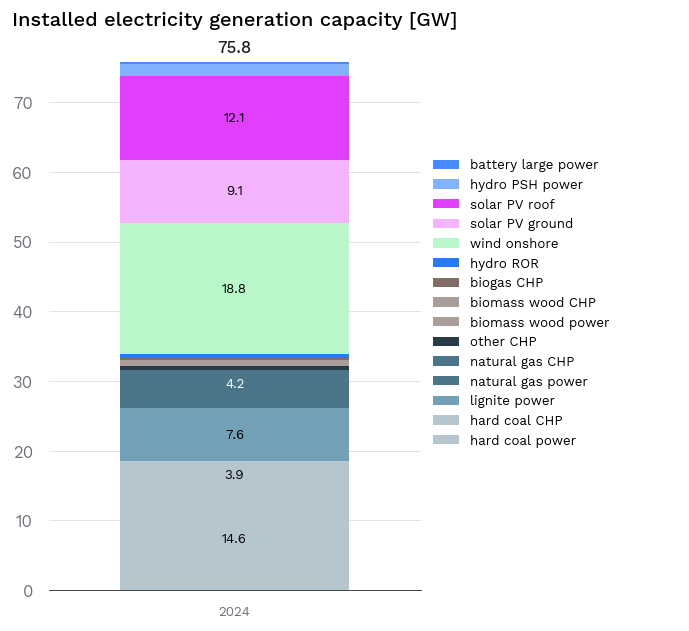

In [27]:
from pypsa_pl.plot_outputs import plot_installed_capacities

fig, df = plot_installed_capacities(
    network,
    bus_carriers=["electricity in"],
    carrier_name="electricity",
    capacity_type="generation",
)

df = append_annual_sum(df)
df

,year,carrier,value
0,2024,biogas CHP,0.34
1,2024,biomass wood CHP,0.80
2,2024,biomass wood heat,2.91
3,2024,hard coal CHP,6.49
4,2024,hard coal heat,3.26
5,2024,heat pump large,0.60
6,2024,heat storage large tank discharge,3.20
7,2024,natural gas CHP,2.26
8,2024,natural gas heat,5.20
9,2024,other CHP,0.60


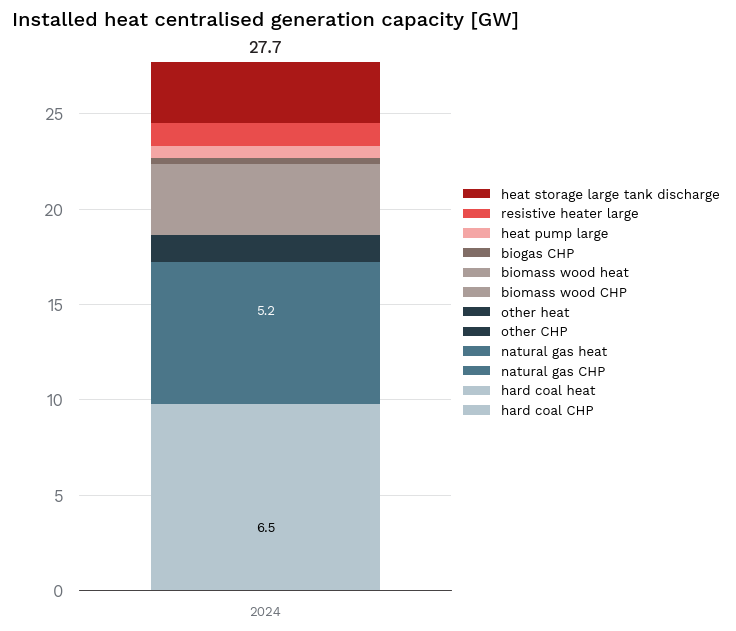

In [28]:
from pypsa_pl.plot_outputs import plot_installed_capacities

fig, df = plot_installed_capacities(
    network,
    bus_carriers=["heat centralised in"],
    carrier_name="heat centralised",
)
df = append_annual_sum(df)
df

,year,carrier,value
0,2024,biomass wood boiler,22.14
1,2024,hard coal boiler,0.00
2,2024,heat pump small,6.15
3,2024,heat storage small discharge,0.00
4,2024,natural gas boiler,0.00
5,2024,other RES heat,1.15
6,2024,other boiler,0.00
7,2024,resistive heater small,9.49
0,2024,SUM,38.93


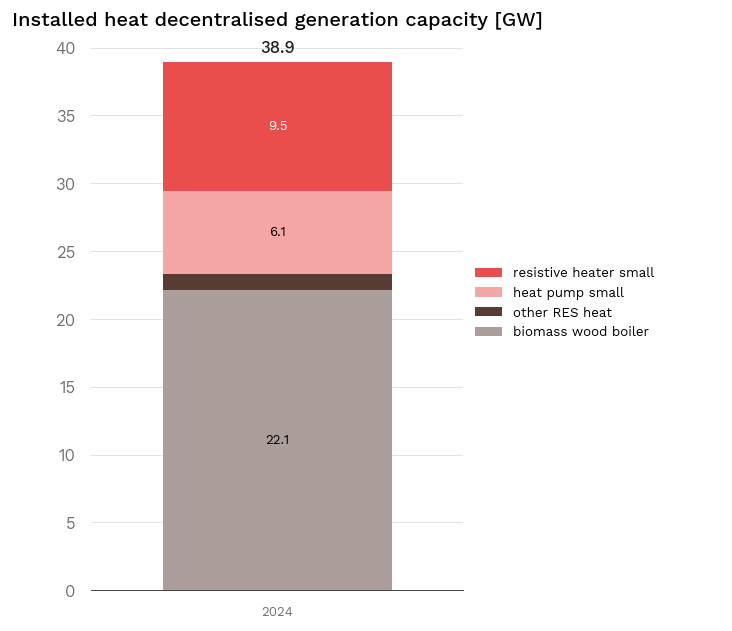

In [29]:
from pypsa_pl.plot_outputs import plot_installed_capacities

fig, df = plot_installed_capacities(
    network,
    bus_carriers=["heat decentralised"],
    carrier_name="heat decentralised",
    capacity_type="generation",
)

df = append_annual_sum(df)
df

,year,carrier,value
0,2024,BEV V2G,0.00
1,2024,battery large power,0.00
2,2024,biogas CHP,0.00
3,2024,biomass wood CHP,0.00
4,2024,biomass wood power,0.00
5,2024,hard coal CHP,-1.28
6,2024,hard coal power,0.00
7,2024,hydro PSH power,0.00
8,2024,hydro ROR,0.00
9,2024,lignite power,0.00


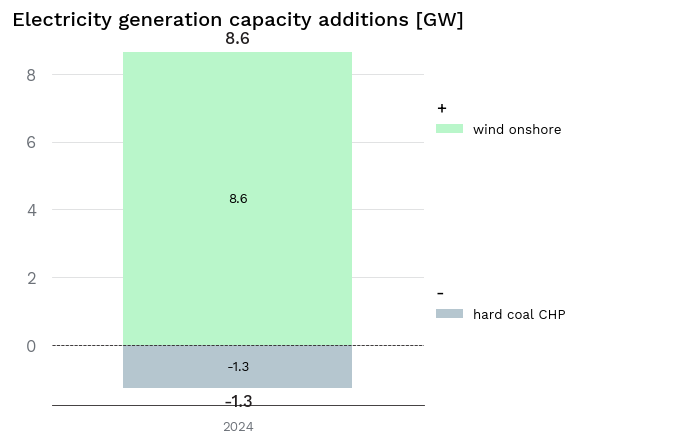

In [30]:
from pypsa_pl.plot_outputs import plot_capacity_additions

fig, df = plot_capacity_additions(
    network,
    bus_carriers=["electricity in"],
    carrier_name="electricity",
    capacity_type="generation",
)

df = append_annual_sum(df)
df

,year,carrier,value
0,2024,biogas CHP,0.00
1,2024,biomass wood CHP,0.00
2,2024,biomass wood heat,0.00
3,2024,hard coal CHP,-2.14
4,2024,hard coal heat,-30.11
5,2024,heat pump large,0.60
6,2024,heat storage large tank discharge,1.20
7,2024,natural gas CHP,0.00
8,2024,natural gas heat,0.00
9,2024,other CHP,0.00


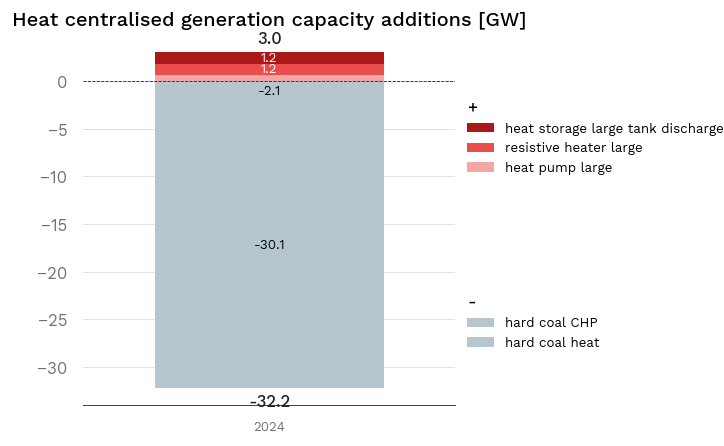

In [31]:
from pypsa_pl.plot_outputs import plot_capacity_additions

fig, df = plot_capacity_additions(
    network,
    bus_carriers=["heat centralised in"],
    carrier_name="heat centralised",
    capacity_type="generation",
)

df = append_annual_sum(df)
df

,year,carrier,value
0,2024,biomass wood boiler,0.00
1,2024,hard coal boiler,-21.29
2,2024,heat pump small,0.00
3,2024,heat storage small discharge,0.00
4,2024,natural gas boiler,-25.36
5,2024,other RES heat,0.00
6,2024,other boiler,-1.30
7,2024,resistive heater small,0.00
0,2024,SUM,-47.95


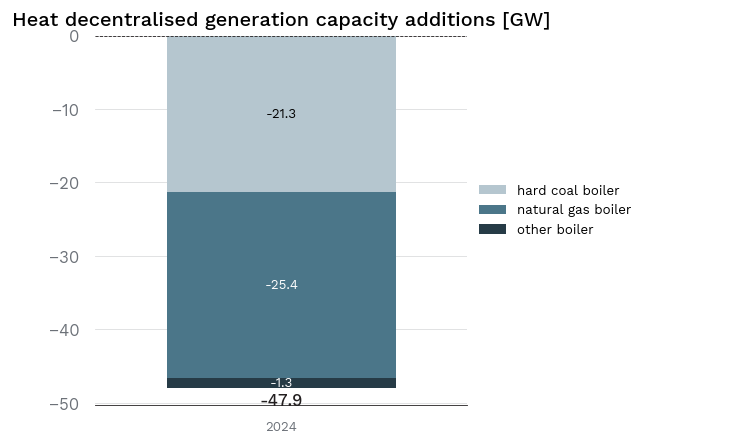

In [32]:
from pypsa_pl.plot_outputs import plot_capacity_additions

fig, df = plot_capacity_additions(
    network,
    bus_carriers=["heat decentralised"],
    carrier_name="heat decentralised",
    capacity_type="generation",
)

df = append_annual_sum(df)
df

,year,carrier,value
0,2024,battery large storage,0.80
1,2024,heat storage large tank,19.20
2,2024,heat storage small,0.00
3,2024,hydro PSH storage,8.47
4,2024,hydrogen storage,0.01
0,2024,SUM,28.48


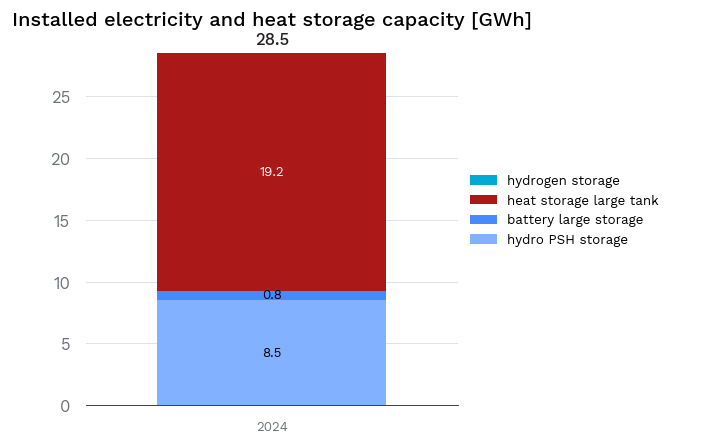

In [33]:
from pypsa_pl.plot_outputs import plot_storage_capacities

fig, df = plot_storage_capacities(
    network,
    bus_carriers=[
        "battery large electricity",
        "hydro PSH electricity",
        "heat storage large tank heat",
        "heat storage small heat",
        "hydrogen",
    ],
    carrier_name="electricity and heat",
)

df = append_annual_sum(df)
df

,year,carrier,value
0,2024,battery large storage,0.0
1,2024,heat storage large tank,7.2
2,2024,heat storage small,0.0
3,2024,hydro PSH storage,0.0
0,2024,SUM,7.2


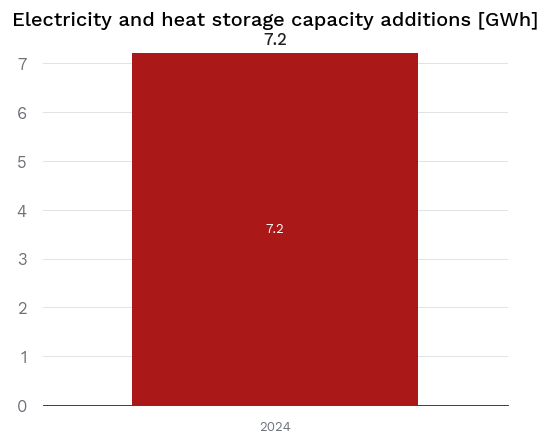

In [34]:
from pypsa_pl.plot_outputs import plot_storage_capacity_additions

fig, df = plot_storage_capacity_additions(
    network,
    bus_carriers=[
        "battery large electricity",
        "hydro PSH electricity",
        "heat storage large tank heat",
        "heat storage small heat",
    ],
    carrier_name="electricity and heat",
)

df = append_annual_sum(df)
df

#### Plot generation mixes

,year,carrier,value
0,2024,BEV V2G,0.00
1,2024,BEV charger,-0.14
2,2024,battery large charger,-0.23
3,2024,battery large power,0.20
4,2024,biogas CHP,1.11
5,2024,biomass wood CHP,1.89
6,2024,biomass wood power,0.74
7,2024,connection HMV-vRES,0.00
8,2024,connection vRES-HMV,0.00
9,2024,direct line vRES,0.00


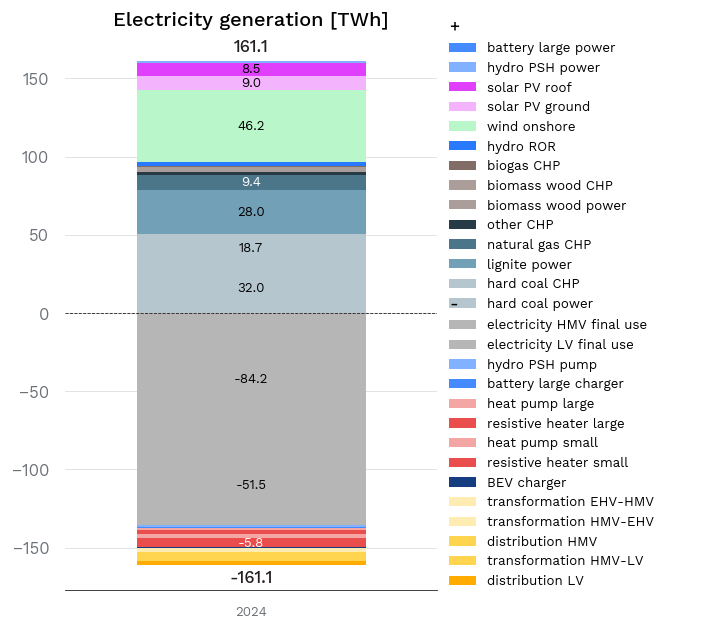

In [35]:
from pypsa_pl.plot_outputs import plot_annual_generation

fig, df = plot_annual_generation(
    network,
    bus_carriers=["electricity in", "electricity out"],
    carrier_name="electricity",
)

df = append_annual_sum(df)
df

,year,carrier,value
0,2024,centralised other heating,24.73
1,2024,centralised space heating,3.56
2,2024,centralised water heating,37.05
3,2024,decentralised space heating,32.06
4,2024,decentralised water heating,25.37
5,2024,other heating final use,-24.73
6,2024,space heating final use,-35.62
7,2024,water heating final use,-62.41
0,2024,SUM,0.01


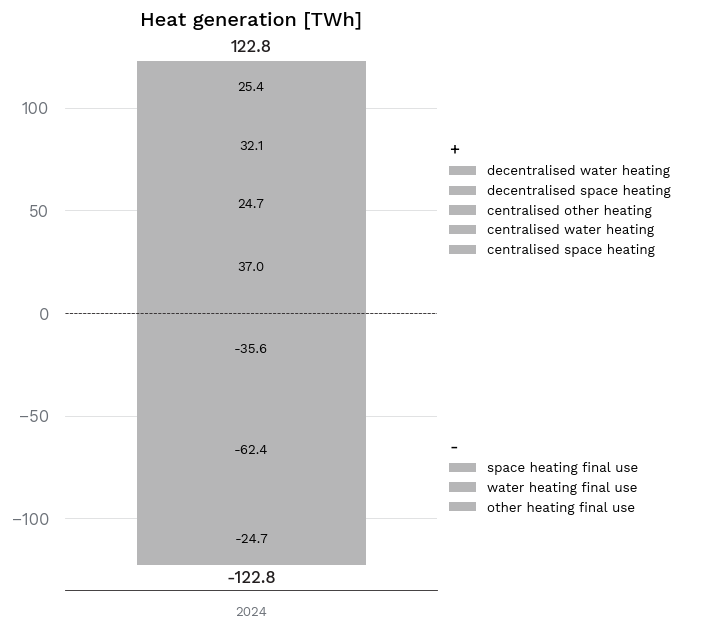

In [36]:
fig, df = plot_annual_generation(
    network,
    bus_carriers=["space heating", "water heating", "other heating"],
    carrier_name="heat",
)

df = append_annual_sum(df)
df

,year,carrier,value
0,2024,biogas CHP,1.30
1,2024,biomass wood CHP,3.26
2,2024,biomass wood heat,2.11
3,2024,centralised other heating,-24.73
4,2024,centralised space heating,-3.56
5,2024,centralised water heating,-37.05
6,2024,district heating,-7.26
7,2024,hard coal CHP,31.11
8,2024,hard coal heat,17.56
9,2024,heat pump large,5.06


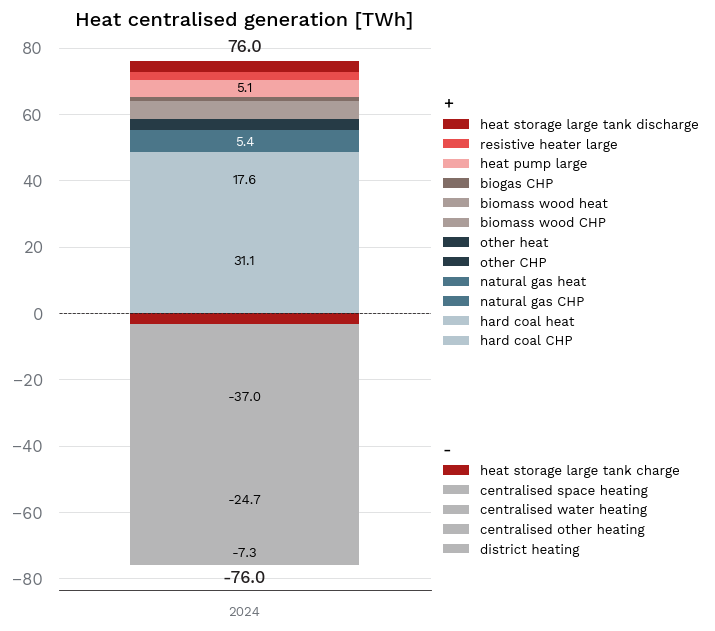

In [37]:
fig, df = plot_annual_generation(
    network,
    bus_carriers=["heat centralised in", "heat centralised out"],
    carrier_name="heat centralised",
)

df = append_annual_sum(df)
df

,year,carrier,value
0,2024,biomass wood boiler,38.79
1,2024,decentralised space heating,-32.06
2,2024,decentralised water heating,-25.37
3,2024,hard coal boiler,0.00
4,2024,heat pump small,10.77
5,2024,heat storage small charge,-0.00
6,2024,heat storage small discharge,0.00
7,2024,natural gas boiler,0.00
8,2024,other RES heat,2.01
9,2024,other boiler,0.00


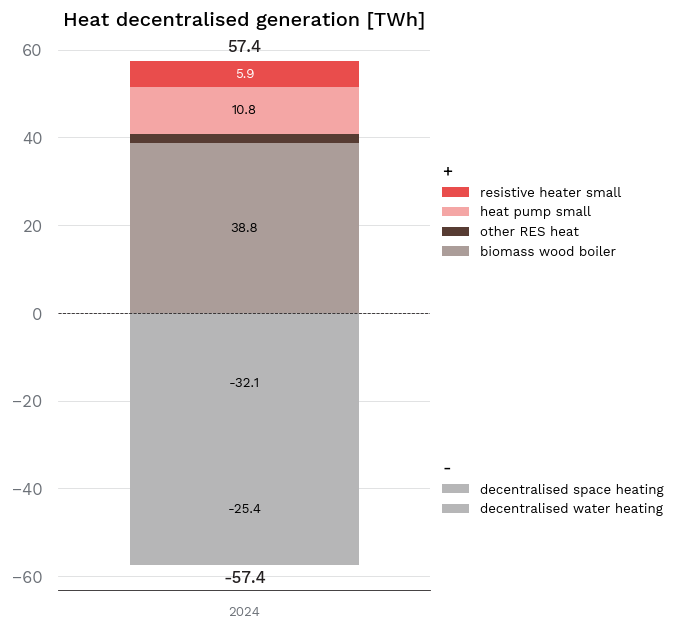

In [38]:
fig, df = plot_annual_generation(
    network,
    bus_carriers=["heat decentralised"],
    carrier_name="heat decentralised",
)

df = append_annual_sum(df)
df

#### Plot fuel consumption and CO2 emissions

,year,fuel,value
0,2024,biogas,9.8
1,2024,biomass wood,229.6
2,2024,hard coal,649.6
3,2024,lignite,287.5
4,2024,natural gas,71.8
5,2024,other fuel,28.9
0,2024,SUM,1277.2


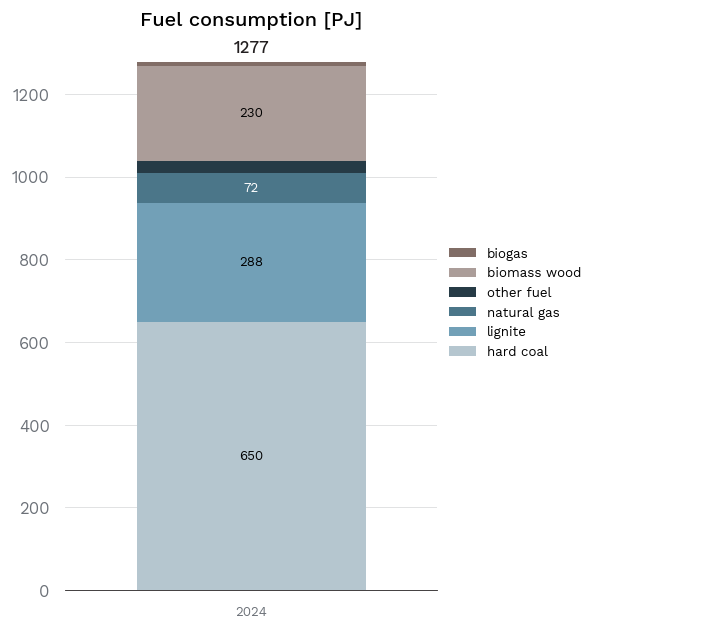

In [39]:
from pypsa_pl.plot_outputs import plot_fuel_consumption

fig, df = plot_fuel_consumption(network)

df = append_annual_sum(df)
df

,year,fuel,value
0,2024,hard coal,61.35
1,2024,lignite,31.95
2,2024,natural gas,3.99
3,2024,other fuel,2.16
0,2024,SUM,99.45


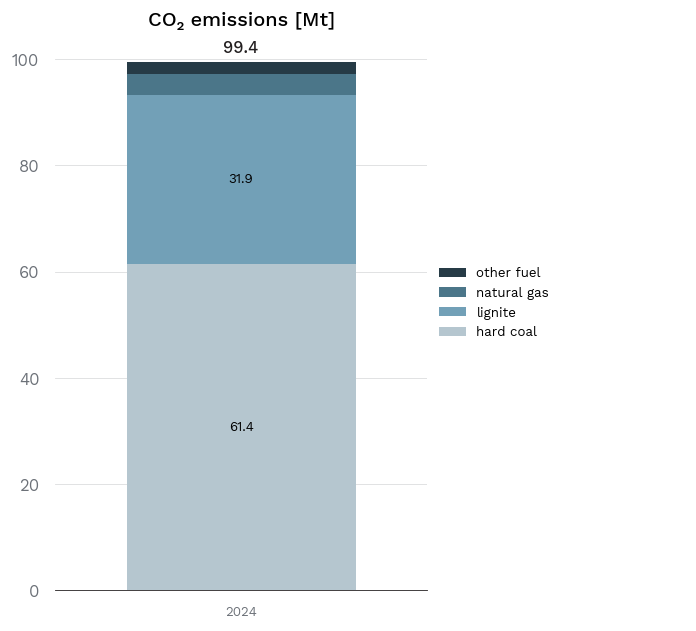

In [40]:
from pypsa_pl.plot_outputs import plot_co2_emissions

fig, df = plot_co2_emissions(network)

df = append_annual_sum(df)
df

#### Plot hourly electricity generation

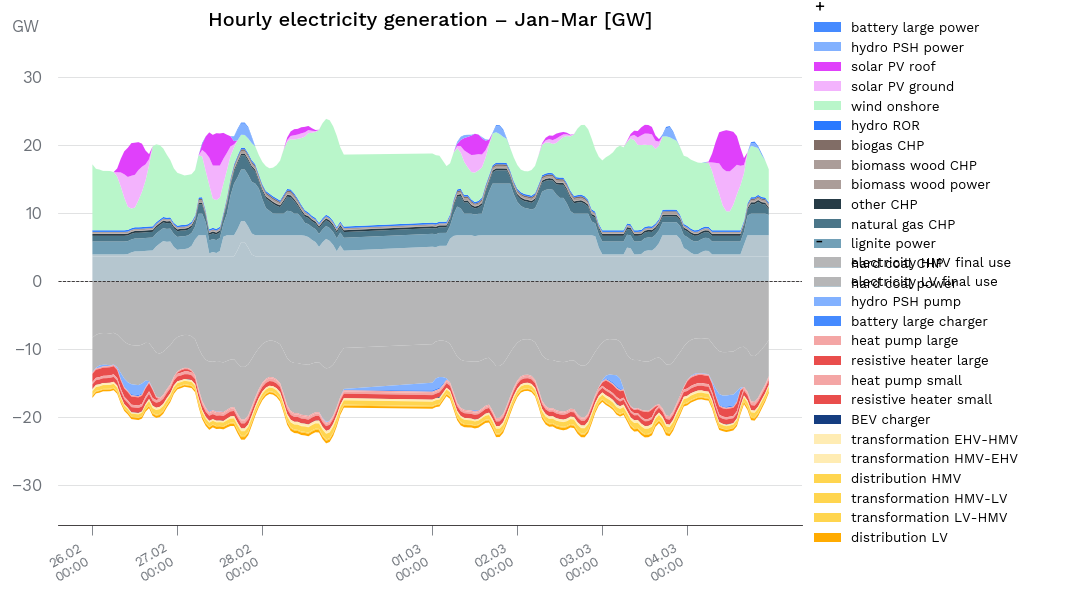

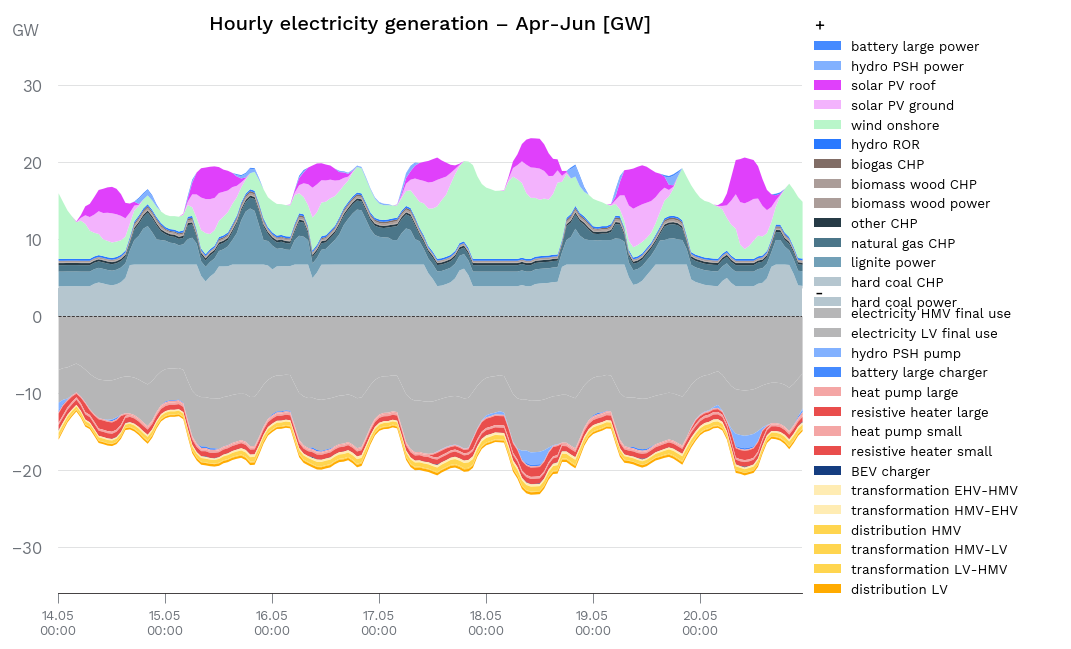

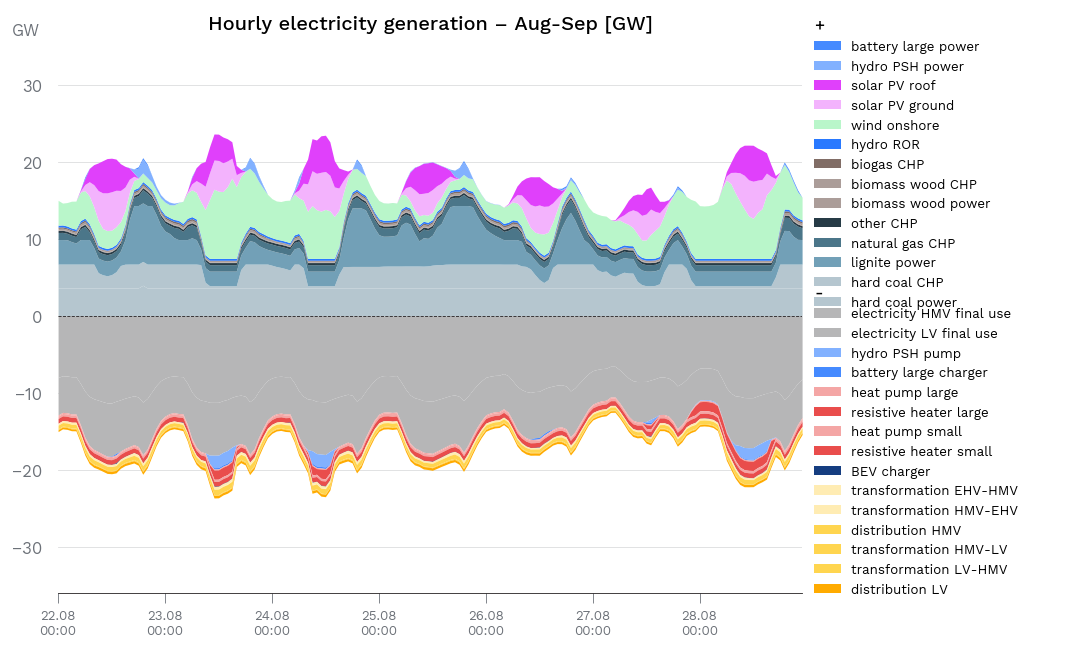

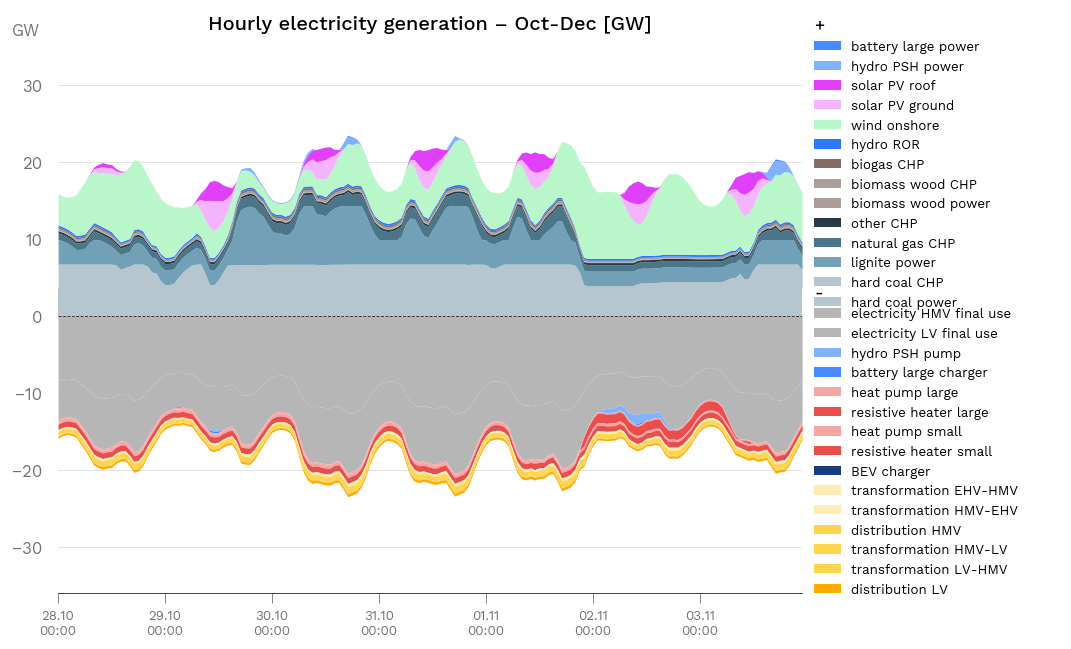

In [41]:
from pypsa_pl.plot_outputs import plot_hourly_generation

n_per_subperiod = 7 * 24
subperiods = [
    (subperiod, (i * n_per_subperiod, (i + 1) * n_per_subperiod))
    for i, subperiod in enumerate(["Jan-Mar", "Apr-Jun", "Aug-Sep", "Oct-Dec"])
]

fig, df = plot_hourly_generation(
    network,
    bus_carriers=["electricity in", "electricity out"],
    carrier_name="electricity",
    subperiods=subperiods,
    ylim=(-36, 36),
)

In [42]:
df

carrier,BEV V2G,BEV charger,battery large charger,battery large power,biogas CHP,biomass wood CHP,biomass wood power,connection HMV-vRES,connection vRES-HMV,direct line vRES,...,resistive heater large,resistive heater small,solar PV ground,solar PV roof,transformation EHV-HMV,transformation HMV-EHV,transformation HMV-LV,transformation LV-HMV,transmission line AC,wind onshore
2024-02-26 00:00:00,0.0,-0.010,-0.000,0.000,0.036,0.182,0.085,0.0,0.0,0.0,...,-1.2,-0.687,0.0,0.0,-0.255,-0.059,-0.130,-0.0,-0.0,9.698
2024-02-26 01:00:00,0.0,-0.011,-0.007,0.000,0.036,0.182,0.085,0.0,0.0,0.0,...,-1.2,-0.688,0.0,0.0,-0.251,-0.056,-0.125,-0.0,0.0,9.040
2024-02-26 02:00:00,0.0,-0.018,-0.037,0.000,0.036,0.182,0.085,0.0,0.0,0.0,...,-1.2,-0.690,0.0,0.0,-0.247,-0.053,-0.123,-0.0,0.0,8.923
2024-02-26 03:00:00,0.0,-0.011,-0.025,0.000,0.036,0.182,0.085,0.0,0.0,0.0,...,-1.2,-0.693,0.0,0.0,-0.247,-0.053,-0.122,-0.0,-0.0,8.729
2024-02-26 04:00:00,0.0,-0.008,-0.020,0.000,0.036,0.182,0.085,0.0,0.0,0.0,...,-1.2,-0.700,0.0,0.0,-0.250,-0.055,-0.122,-0.0,-0.0,8.726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-03 19:00:00,0.0,-0.014,-0.000,0.047,0.195,0.277,0.085,0.0,0.0,0.0,...,-0.0,-0.692,0.0,0.0,-0.288,-0.055,-0.163,-0.0,0.0,6.516
2024-11-03 20:00:00,0.0,-0.013,-0.000,0.052,0.189,0.276,0.085,0.0,0.0,0.0,...,-0.0,-0.692,0.0,0.0,-0.280,-0.050,-0.157,-0.0,0.0,6.446
2024-11-03 21:00:00,0.0,-0.012,-0.000,0.037,0.182,0.268,0.085,0.0,0.0,0.0,...,-0.0,-0.688,0.0,0.0,-0.267,-0.041,-0.148,-0.0,0.0,6.327
2024-11-03 22:00:00,0.0,-0.011,-0.000,0.000,0.181,0.236,0.085,0.0,0.0,0.0,...,-0.0,-0.679,0.0,0.0,-0.242,-0.047,-0.140,-0.0,0.0,6.556


#### Plot centralised heat generation

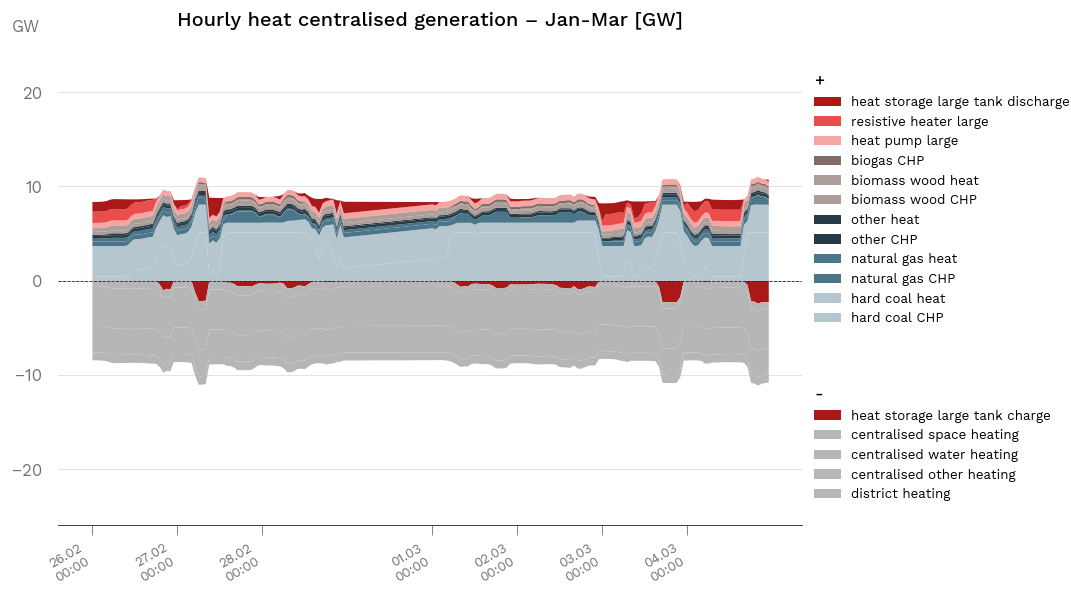

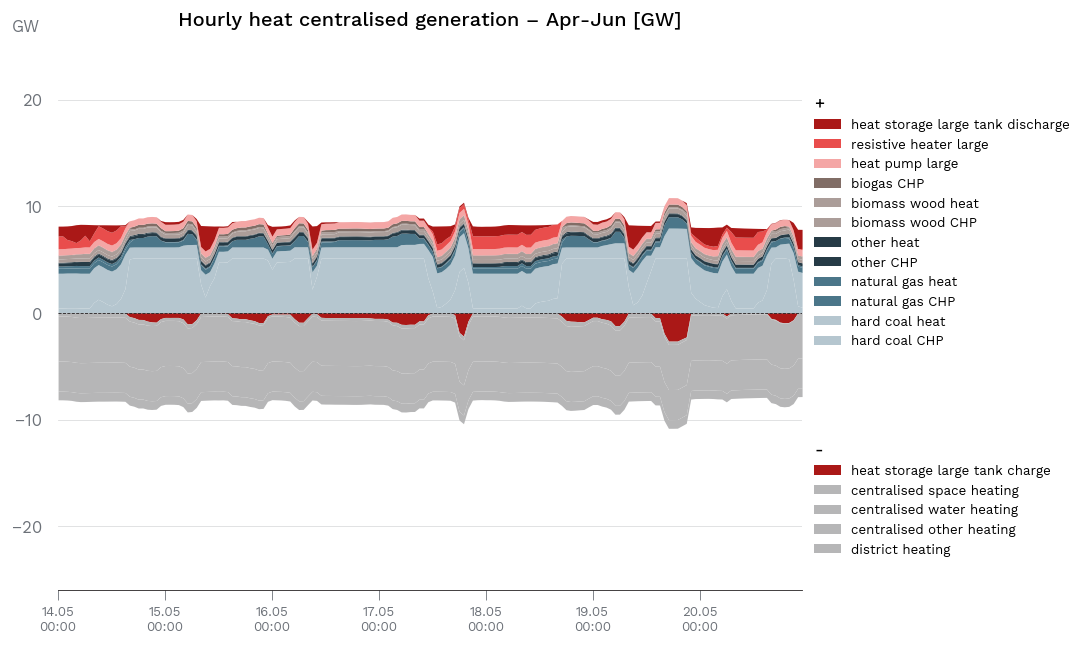

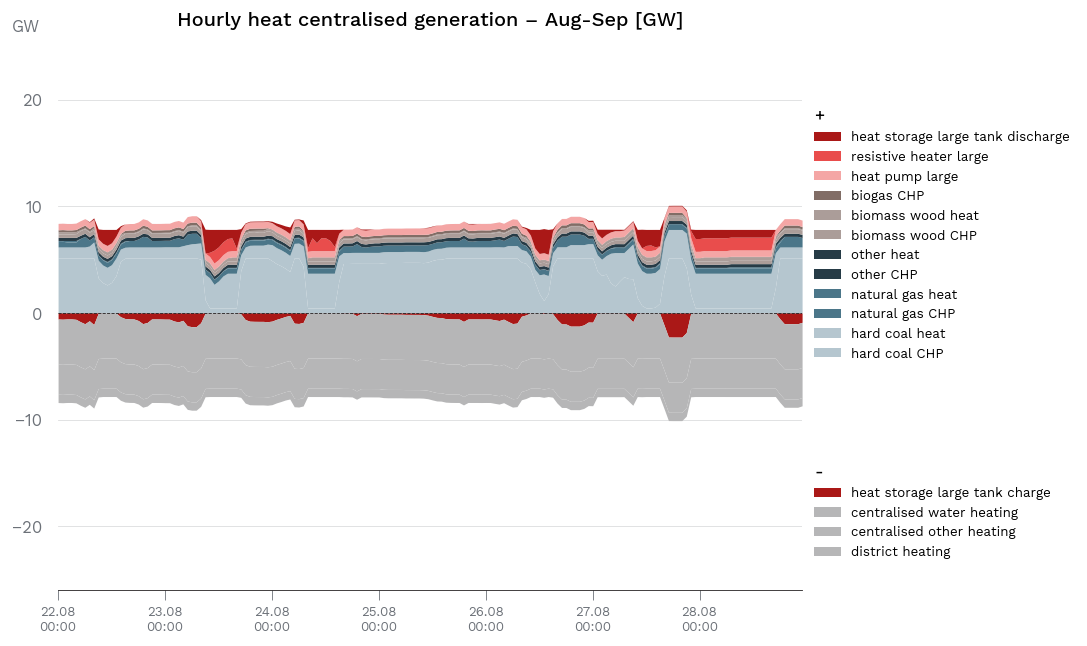

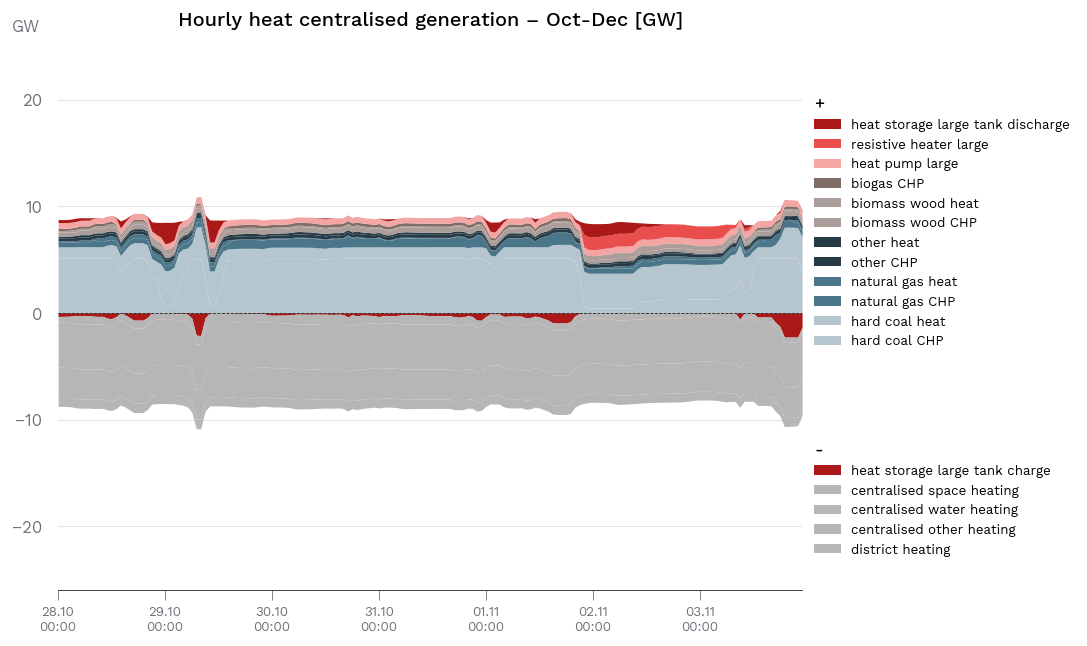

In [43]:
from pypsa_pl.plot_outputs import plot_hourly_generation

n_per_subperiod = 7 * 24
subperiods = [
    (subperiod, (i * n_per_subperiod, (i + 1) * n_per_subperiod))
    for i, subperiod in enumerate(["Jan-Mar", "Apr-Jun", "Aug-Sep", "Oct-Dec"])
]

fig, df = plot_hourly_generation(
    network,
    bus_carriers=["heat centralised in", "heat centralised out"],
    carrier_name="heat centralised",
    subperiods=subperiods,
    ylim=(-26, 26),
)

#### Plot total overnight investment costs

,year,aggregation,value
23,2024,heat pump large,3.36
25,2024,heat storage large,0.28
48,2024,resistive heater large,0.55
53,2024,wind onshore,63.84
0,2024,SUM,68.03


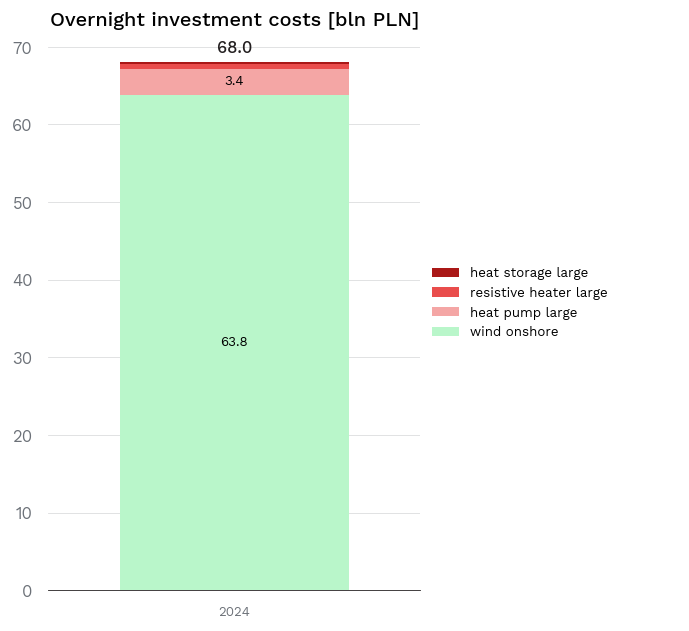

In [44]:
from pypsa_pl.plot_outputs import plot_capex

fig, df = plot_capex(network, cost_attr="investment_cost")

df = append_annual_sum(df)

df

#### Plot total annual costs

Objective value: 71.8


,year,aggregation,value
0,2024,BEV,0.0590
3,2024,battery large,0.0034
4,2024,biogas CHP,0.0731
5,2024,biogas production,0.2651
6,2024,biogas substrate supply,0.6026
7,2024,biomass CHP,0.5055
8,2024,biomass heat,0.7074
9,2024,biomass power,0.2324
10,2024,biomass supply,11.4817
11,2024,biomass wood boiler,5.0922


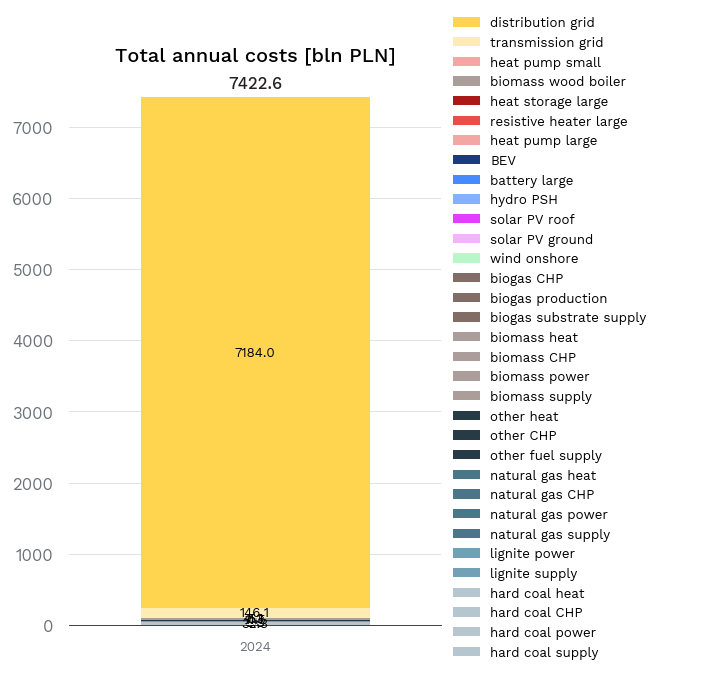

In [45]:
from pypsa_pl.plot_outputs import plot_total_costs

fig, df = plot_total_costs(network, costs=["OPEX", "CAPEX"])

# In this example distribution grids are considered infinite, so the values for them are meaningless
df = df[df["aggregation"] != "distribution grid"]
# ***

df = append_annual_sum(df)

# Objective and objective_constant values cover operational costs of all capacities and capital costs
# of the extendable capacities only - that's why their sum might differ from the total annual cost
if not hasattr(network, "objective_constant"):
    network.objective_constant = 0
objective_value = np.round((network.objective + network.objective_constant) / 1e9, 1)
print("Objective value:", objective_value)

df

#### Plot annual cost structure

cost component,year,aggregation,Var. O&M,CO₂,Fix. O&M,Ann. invest.,SUM
0,2024,BEV,0.0000,0.0000,0.0590,0.0000,0.0590
1,2024,battery large,0.0027,0.0000,0.0007,0.0000,0.0034
2,2024,biogas CHP,0.0545,0.0000,0.0186,0.0000,0.0731
3,2024,biogas production,0.0060,0.0000,0.2591,0.0000,0.2651
4,2024,biogas substrate supply,0.6026,0.0000,0.0000,0.0000,0.6026
5,2024,biomass CHP,0.0547,0.0000,0.4508,0.0000,0.5055
6,2024,biomass heat,0.0381,0.0000,0.6693,0.0000,0.7074
7,2024,biomass power,0.0216,0.0000,0.2108,0.0000,0.2324
8,2024,biomass supply,11.4817,0.0000,0.0000,0.0000,11.4817
9,2024,biomass wood boiler,0.0000,0.0000,5.0922,0.0000,5.0922


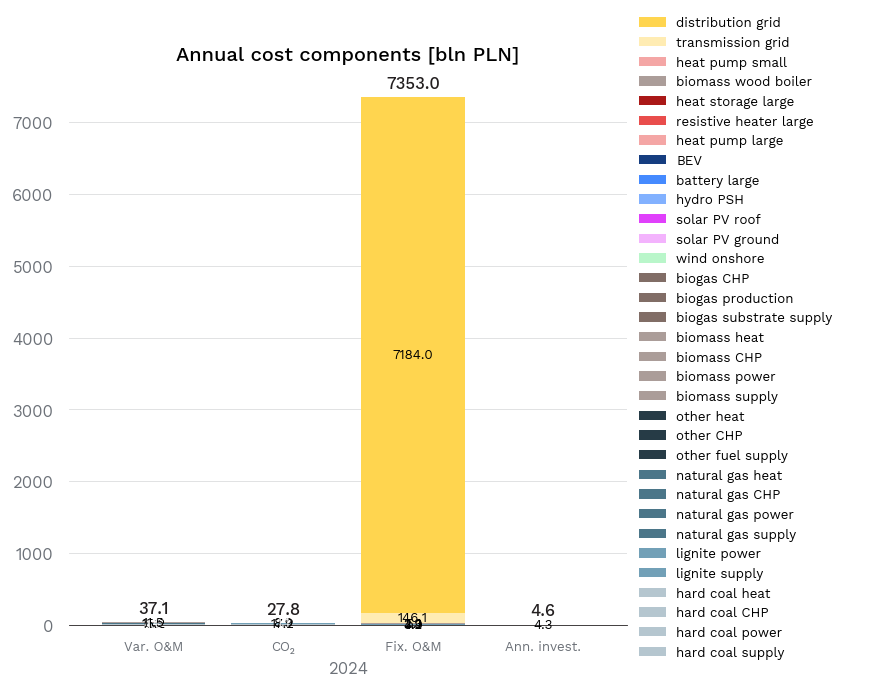

In [46]:
from pypsa_pl.plot_outputs import plot_detailed_costs

fig, df = plot_detailed_costs(network)

# In this example distribution grids are considered infinite, so the values for them are meaningless
df = df[df["aggregation"] != "distribution grid"]
# ***

df = df.pivot(index="aggregation", columns="cost component", values="value").fillna(0)


columns = list(df.columns)

df["SUM"] = df.sum(axis=1)
df = df.reset_index().assign(year=params["year"])
df = append_annual_sum(df, value_cols=columns + ["SUM"])
df = df.set_index(["year", "aggregation"]).reset_index()

df

#### Plot network

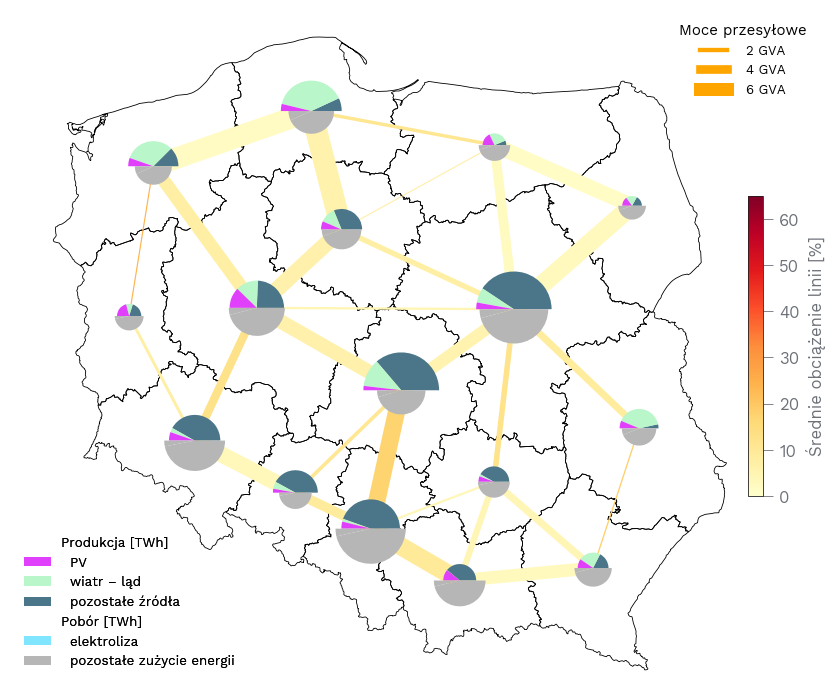

In [47]:
from pypsa_pl.plot_outputs import plot_power_system

fig = plot_power_system(network, transmission_agg="mean")

fig